In [1]:
# ============================================================
# 00. GOOGLE DRIVE
# ============================================================

import os

DRIVE_ROOT = "/content/drive"

if os.path.exists(os.path.join(DRIVE_ROOT, "MyDrive")):
    print("✅ Google Drive is already mounted.")
else:
    from google.colab import drive
    drive.mount(DRIVE_ROOT)
    print("✅ Google Drive mounted.")

Mounted at /content/drive
✅ Google Drive mounted.


In [2]:
# ============================================================
# 01. PROJECT PATHS
# ============================================================

import os
import pandas as pd
import numpy as np

PROJECT_PATH = (
    "/content/drive/MyDrive/"
    "AMEX_Credit_Risk_Capstone_Project"
)

DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data"
)

RAW_PATH = os.path.join(
    DATA_PATH,
    "raw"
)

PROCESSED_PATH = os.path.join(
    DATA_PATH,
    "processed"
)

RESULTS_PATH = os.path.join(
    PROJECT_PATH,
    "results"
)

RESULTS_TABLE_PATH = os.path.join(
    RESULTS_PATH,
    "tables"
)

RESULTS_FIGURE_PATH = os.path.join(
    RESULTS_PATH,
    "figures"
)

# Create result folders if necessary
os.makedirs(RESULTS_TABLE_PATH, exist_ok=True)
os.makedirs(RESULTS_FIGURE_PATH, exist_ok=True)

print("PROJECT_PATH:")
print(PROJECT_PATH)

print("\nDATA_PATH:")
print(DATA_PATH)

print("\nPROCESSED_PATH:")
print(PROCESSED_PATH)

print("\nRESULTS_PATH:")
print(RESULTS_PATH)

PROJECT_PATH:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project

DATA_PATH:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/data

PROCESSED_PATH:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/data/processed

RESULTS_PATH:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results


In [3]:
# ============================================================
# 02. CHECK PROJECT FOLDERS
# ============================================================

folders = {
    "Project": PROJECT_PATH,
    "Data": DATA_PATH,
    "Raw": RAW_PATH,
    "Processed": PROCESSED_PATH,
    "Results": RESULTS_PATH
}

for name, path in folders.items():
    print(
        f"{name}:",
        "✅ FOUND" if os.path.isdir(path)
        else "❌ NOT FOUND"
    )

Project: ✅ FOUND
Data: ✅ FOUND
Raw: ✅ FOUND
Processed: ✅ FOUND
Results: ✅ FOUND


In [4]:

# ============================================================
# 03. VERIFIED DATA FILES
# ============================================================

MASTER_DATA = os.path.join(
    PROCESSED_PATH,
    "train_data_100k_no_90pct_missing_v2.csv"
)

TRAIN_IDS = os.path.join(
    PROCESSED_PATH,
    "train_customer_ids.csv"
)

VALIDATION_IDS = os.path.join(
    PROCESSED_PATH,
    "validation_customer_ids.csv"
)

TEST_IDS = os.path.join(
    PROCESSED_PATH,
    "test_customer_ids.csv"
)

print("Master dataset:")
print(MASTER_DATA)

print("\nTrain customer IDs:")
print(TRAIN_IDS)

print("\nValidation customer IDs:")
print(VALIDATION_IDS)

print("\nTest customer IDs:")
print(TEST_IDS)

Master dataset:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/data/processed/train_data_100k_no_90pct_missing_v2.csv

Train customer IDs:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/data/processed/train_customer_ids.csv

Validation customer IDs:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/data/processed/validation_customer_ids.csv

Test customer IDs:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/data/processed/test_customer_ids.csv


In [5]:
# ============================================================
# 04. CHECK REQUIRED FILES
# ============================================================

required_files = {
    "Master dataset": MASTER_DATA,
    "Train customer IDs": TRAIN_IDS,
    "Validation customer IDs": VALIDATION_IDS,
    "Test customer IDs": TEST_IDS
}

all_found = True

for name, path in required_files.items():

    if os.path.isfile(path):
        size_gb = os.path.getsize(path) / (1024 ** 3)

        print(
            f"✅ {name} | {size_gb:.2f} GB"
        )

    else:
        print(
            f"❌ {name} NOT FOUND"
        )

        all_found = False

print("\nAll required files available:", all_found)

✅ Master dataset | 3.27 GB
✅ Train customer IDs | 0.00 GB
✅ Validation customer IDs | 0.00 GB
✅ Test customer IDs | 0.00 GB

All required files available: True


In [6]:
source_file = os.path.join(
    PROCESSED_PATH,
    "train_data_100k_no_90pct_missing_v2.csv"
)

df_check = pd.read_csv(
    source_file,
    usecols=["customer_ID"],
    low_memory=False
)

print("Rows:", len(df_check))
print("Unique customers:", df_check["customer_ID"].nunique())
print("Duplicate customer rows:", df_check["customer_ID"].duplicated().sum())
print("Missing customer IDs:", df_check["customer_ID"].isna().sum())

del df_check

Rows: 1205473
Unique customers: 100000
Duplicate customer rows: 1105473
Missing customer IDs: 0


In [7]:
# STEP 2: Load training customers

train_ids_df = pd.read_csv(
    TRAIN_IDS,
    usecols=["customer_ID", "target"]
)

print("Training rows:", len(train_ids_df))
print("Unique customers:", train_ids_df["customer_ID"].nunique())

print("\nTarget distribution:")
print(train_ids_df["target"].value_counts())

print("\nTarget percentage:")
print(
    train_ids_df["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training rows: 70000
Unique customers: 70000

Target distribution:
target
0    51875
1    18125
Name: count, dtype: int64

Target percentage:
target
0    74.11
1    25.89
Name: proportion, dtype: float64


In [8]:
# STEP 3: Verify validation and test customer splits

val_ids_df = pd.read_csv(
    VALIDATION_IDS,
    usecols=["customer_ID", "target"]
)

test_ids_df = pd.read_csv(
    TEST_IDS,
    usecols=["customer_ID", "target"]
)

print("Validation customers:", len(val_ids_df))
print("Validation unique:", val_ids_df["customer_ID"].nunique())

print("\nTest customers:", len(test_ids_df))
print("Test unique:", test_ids_df["customer_ID"].nunique())

print("\nValidation target distribution:")
print(val_ids_df["target"].value_counts())

print("\nTest target distribution:")
print(test_ids_df["target"].value_counts())

Validation customers: 15000
Validation unique: 15000

Test customers: 15000
Test unique: 15000

Validation target distribution:
target
0    11116
1     3884
Name: count, dtype: int64

Test target distribution:
target
0    11116
1     3884
Name: count, dtype: int64


In [9]:
# STEP 4: Check customer overlap between splits

train_customers = set(train_ids_df["customer_ID"])
val_customers = set(val_ids_df["customer_ID"])
test_customers = set(test_ids_df["customer_ID"])

print("Train ∩ Validation:", len(train_customers & val_customers))
print("Train ∩ Test:", len(train_customers & test_customers))
print("Validation ∩ Test:", len(val_customers & test_customers))

print("\nTotal unique customers across all splits:",
      len(train_customers | val_customers | test_customers))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Total unique customers across all splits: 100000


In [10]:
# STEP 5: Inspect the cleaned master dataset columns

source_file = os.path.join(
    PROCESSED_PATH,
    "train_data_100k_no_90pct_missing_v2.csv"
)

sample_df = pd.read_csv(
    source_file,
    nrows=5,
    low_memory=False
)

print("Number of columns:", len(sample_df.columns))
print("\nColumns:")
print(sample_df.columns.tolist())

Number of columns: 172

Columns:
['customer_ID', 'S_2', 'P_2', 'D_39', 'B_1', 'B_2', 'R_1', 'S_3', 'D_41', 'B_3', 'D_42', 'D_43', 'D_44', 'B_4', 'D_45', 'B_5', 'R_2', 'D_46', 'D_47', 'D_48', 'B_6', 'B_7', 'B_8', 'D_50', 'D_51', 'B_9', 'R_3', 'D_52', 'P_3', 'B_10', 'D_53', 'S_5', 'B_11', 'S_6', 'D_54', 'R_4', 'S_7', 'B_12', 'S_8', 'D_55', 'D_56', 'B_13', 'R_5', 'D_58', 'S_9', 'B_14', 'D_59', 'D_60', 'D_61', 'B_15', 'S_11', 'D_62', 'D_63', 'D_64', 'D_65', 'B_16', 'B_17', 'B_18', 'B_19', 'D_66', 'B_20', 'D_68', 'S_12', 'R_6', 'S_13', 'B_21', 'D_69', 'B_22', 'D_70', 'D_71', 'D_72', 'S_15', 'B_23', 'P_4', 'D_74', 'D_75', 'D_76', 'B_24', 'R_7', 'D_77', 'B_25', 'B_26', 'D_78', 'D_79', 'R_8', 'S_16', 'D_80', 'R_10', 'R_11', 'B_27', 'D_81', 'D_82', 'S_17', 'R_12', 'B_28', 'R_13', 'D_83', 'R_14', 'R_15', 'D_84', 'R_16', 'B_30', 'S_18', 'D_86', 'R_17', 'R_18', 'B_31', 'S_19', 'R_19', 'B_32', 'S_20', 'R_20', 'R_21', 'B_33', 'D_89', 'R_22', 'R_23', 'D_91', 'D_92', 'D_93', 'D_94', 'R_24', 'R_25', 'D

In [11]:
# STEP 6: Identify variable types

print("Object / categorical columns:")
print(sample_df.select_dtypes(include=["object"]).columns.tolist())

print("\nNumeric columns:")
print("Number of numeric columns:",
      len(sample_df.select_dtypes(include=["number"]).columns))

print("\nNumber of categorical/object columns:",
      len(sample_df.select_dtypes(include=["object"]).columns))

Object / categorical columns:
['customer_ID', 'S_2', 'D_63', 'D_64']

Numeric columns:
Number of numeric columns: 168

Number of categorical/object columns: 4


In [12]:
# STEP 7: Create numeric feature list

numeric_cols = sample_df.select_dtypes(include=["number"]).columns.tolist()

print("Number of numeric variables:", len(numeric_cols))
print("\nFirst 20 numeric variables:")
print(numeric_cols[:20])

Number of numeric variables: 168

First 20 numeric variables:
['P_2', 'D_39', 'B_1', 'B_2', 'R_1', 'S_3', 'D_41', 'B_3', 'D_42', 'D_43', 'D_44', 'B_4', 'D_45', 'B_5', 'R_2', 'D_46', 'D_47', 'D_48', 'B_6', 'B_7']


In [13]:
# STEP 8: Check statement date range

date_check = pd.read_csv(
    source_file,
    usecols=["S_2"],
    low_memory=False
)

date_check["S_2"] = pd.to_datetime(date_check["S_2"])

print("Earliest statement date:", date_check["S_2"].min())
print("Latest statement date:", date_check["S_2"].max())
print("Number of unique months:", date_check["S_2"].dt.to_period("M").nunique())

del date_check

Earliest statement date: 2017-03-01 00:00:00
Latest statement date: 2018-03-31 00:00:00
Number of unique months: 13


In [14]:
# STEP 9: Check observations per customer

obs_check = pd.read_csv(
    source_file,
    usecols=["customer_ID"],
    low_memory=False
)

obs_counts = obs_check["customer_ID"].value_counts()

print("Minimum observations:", obs_counts.min())
print("Maximum observations:", obs_counts.max())
print("Mean observations:", round(obs_counts.mean(), 2))
print("Median observations:", obs_counts.median())

print("\nObservation count distribution:")
print(obs_counts.value_counts().sort_index())

del obs_check, obs_counts

Minimum observations: 1
Maximum observations: 13
Mean observations: 12.05
Median observations: 13.0

Observation count distribution:
count
1      1119
2      1308
3      1264
4      1032
5      1021
6      1205
7      1156
8      1284
9      1432
10     1403
11     1301
12     2285
13    84190
Name: count, dtype: int64


In [15]:
# STEP 10: Check missingness of numeric variables

missing_check = pd.read_csv(
    source_file,
    usecols=numeric_cols,
    low_memory=False
)

missing_pct = (
    missing_check.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Top 20 numeric variables by missing percentage:")
print(missing_pct.head(20))

print("\nVariables with >50% missing:",
      (missing_pct > 50).sum())

print("Variables with >80% missing:",
      (missing_pct > 80).sum())

del missing_check, missing_pct

Top 20 numeric variables by missing percentage:
R_26     88.878059
D_76     88.733302
D_66     88.652172
D_42     85.785414
D_142    83.080915
D_53     73.648352
D_82     73.174181
B_17     56.786340
D_50     56.742789
D_105    54.681026
D_56     54.080680
S_9      53.183107
D_77     45.535238
D_43     30.019835
S_27     25.501525
D_46     21.868180
S_3      18.581420
S_7      18.581420
D_62     13.651073
D_48     12.920737
dtype: float64

Variables with >50% missing: 12
Variables with >80% missing: 5


In [16]:
# STEP 11: List variables with more than 50% missing

missing_check = pd.read_csv(
    source_file,
    usecols=numeric_cols,
    low_memory=False
)

missing_pct = (
    missing_check.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

high_missing_cols = missing_pct[missing_pct > 50].index.tolist()

print("Variables with >50% missing:")
for col in high_missing_cols:
    print(f"{col}: {missing_pct[col]:.2f}%")

del missing_check, missing_pct

Variables with >50% missing:
R_26: 88.88%
D_76: 88.73%
D_66: 88.65%
D_42: 85.79%
D_142: 83.08%
D_53: 73.65%
D_82: 73.17%
B_17: 56.79%
D_50: 56.74%
D_105: 54.68%
D_56: 54.08%
S_9: 53.18%


In [17]:
# STEP 12: Check missingness vs default rate

high_missing_cols = [
    "R_26", "D_76", "D_66", "D_42", "D_142",
    "D_53", "D_82", "B_17", "D_50", "D_105",
    "D_56", "S_9"
]

# Create a set for fast customer lookup
train_customer_set = set(train_ids_df["customer_ID"])

missing_default_stats = []

for chunk in pd.read_csv(
    source_file,
    usecols=["customer_ID"] + high_missing_cols,
    chunksize=100000,
    low_memory=False
):
    chunk = chunk[chunk["customer_ID"].isin(train_customer_set)]

    if len(chunk) == 0:
        continue

    # Missingness indicator for each variable
    for col in high_missing_cols:
        chunk[col + "_missing"] = chunk[col].isna().astype(int)

    missing_default_stats.append(chunk)

    del chunk

missing_df = pd.concat(missing_default_stats, ignore_index=True)

# Add target
missing_df = missing_df.merge(
    train_ids_df,
    on="customer_ID",
    how="left"
)

for col in high_missing_cols:
    indicator = col + "_missing"

    rates = (
        missing_df.groupby(indicator)["target"]
        .agg(["count", "mean"])
    )

    print(f"\n{col}")
    print(rates)

del missing_df, missing_default_stats


R_26
               count      mean
R_26_missing                  
0              95062  0.582262
1             749111  0.206919

D_76
               count      mean
D_76_missing                  
0              93308  0.101867
1             750865  0.267493

D_66
               count      mean
D_66_missing                  
0              95693  0.181915
1             748480  0.257786

D_42
               count      mean
D_42_missing                  
0             119597  0.499201
1             724576  0.207919

D_142
                count      mean
D_142_missing                  
0              142948  0.371548
1              701225  0.224242

D_53
               count      mean
D_53_missing                  
0             222767  0.435477
1             621406  0.182402

D_82
               count      mean
D_82_missing                  
0             226725  0.204389
1             617448  0.265635

B_17
               count      mean
B_17_missing                  
0             364

In [18]:
# STEP 13: Save missingness vs default analysis

missingness_results = []

for col in high_missing_cols:
    # Recalculate from the previous result at customer/monthly observation level
    pass

print("Step 13 will be done after we create the customer-level screening data.")

Step 13 will be done after we create the customer-level screening data.


In [20]:
import pandas as pd
import numpy as np
import os
import gc

# =========================================================
# STEP 13 — OPTIMIZED CUSTOMER-LEVEL SCREENING DATASET
# =========================================================

SOURCE_FILE = os.path.join(
    PROCESSED_PATH,
    "train_data_100k_no_90pct_missing_v2.csv"
)

TRAIN_IDS_FILE = os.path.join(
    PROCESSED_PATH,
    "train_customer_ids.csv"
)

OUTPUT_FILE = os.path.join(
    PROCESSED_PATH,
    "train_customer_screening_70k.csv"
)

# ---------------------------------------------------------
# 1. Load training customer IDs
# ---------------------------------------------------------

train_ids_df = pd.read_csv(TRAIN_IDS_FILE)

train_customer_ids = set(train_ids_df["customer_ID"])

print("Training customers:", len(train_customer_ids))
print("\nTarget distribution:")
print(train_ids_df["target"].value_counts())


# ---------------------------------------------------------
# 2. Identify numeric columns
# ---------------------------------------------------------

all_columns = pd.read_csv(
    SOURCE_FILE,
    nrows=0
).columns.tolist()

exclude_cols = [
    "customer_ID",
    "S_2",
    "D_63",
    "D_64"
]

numeric_cols = [
    col for col in all_columns
    if col not in exclude_cols
]

print("\nNumber of numeric features:", len(numeric_cols))


# ---------------------------------------------------------
# 3. Initialize accumulators
# ---------------------------------------------------------

customer_index = pd.Index(
    train_ids_df["customer_ID"],
    name="customer_ID"
)

# For mean
sums = pd.DataFrame(
    0.0,
    index=customer_index,
    columns=numeric_cols
)

counts = pd.DataFrame(
    0,
    index=customer_index,
    columns=numeric_cols,
    dtype=np.int32
)

# Number of monthly observations
observation_count = pd.Series(
    0,
    index=customer_index,
    dtype=np.int32
)

# Latest observation
latest_date = pd.Series(
    pd.NaT,
    index=customer_index,
    dtype="datetime64[ns]"
)

latest_values = pd.DataFrame(
    np.nan,
    index=customer_index,
    columns=numeric_cols
)


# ---------------------------------------------------------
# 4. Process master file in chunks
# ---------------------------------------------------------

use_cols = [
    "customer_ID",
    "S_2"
] + numeric_cols

chunk_size = 100_000

for chunk_no, chunk in enumerate(
    pd.read_csv(
        SOURCE_FILE,
        usecols=use_cols,
        chunksize=chunk_size,
        low_memory=False
    ),
    start=1
):

    # Keep only training customers
    chunk = chunk[
        chunk["customer_ID"].isin(train_customer_ids)
    ].copy()

    if chunk.empty:
        del chunk
        continue

    chunk["S_2"] = pd.to_datetime(chunk["S_2"])

    # -----------------------------------------------------
    # A. Observation counts
    # -----------------------------------------------------

    obs = chunk["customer_ID"].value_counts()

    observation_count.loc[obs.index] += obs.astype(np.int32)


    # -----------------------------------------------------
    # B. Mean statistics
    # -----------------------------------------------------

    grouped = chunk.groupby(
        "customer_ID",
        sort=False
    )

    chunk_sum = grouped[numeric_cols].sum()
    chunk_count = grouped[numeric_cols].count()

    common_ids = chunk_sum.index

    sums.loc[common_ids] += chunk_sum
    counts.loc[common_ids] += chunk_count.astype(np.int32)


    # -----------------------------------------------------
    # C. Latest monthly observation
    # -----------------------------------------------------

    # Sort by customer and date
    chunk = chunk.sort_values(
        ["customer_ID", "S_2"]
    )

    # Latest row for each customer in THIS chunk
    latest_chunk = (
        chunk
        .drop_duplicates(
            subset="customer_ID",
            keep="last"
        )
        .set_index("customer_ID")
    )

    latest_ids = latest_chunk.index

    # Existing latest dates
    existing_dates = latest_date.loc[latest_ids]

    # Customers whose current chunk contains a newer observation
    update_mask = (
        existing_dates.isna()
        |
        (
            latest_chunk["S_2"]
            > existing_dates
        )
    )

    update_ids = latest_ids[update_mask]

    if len(update_ids) > 0:

        latest_date.loc[update_ids] = (
            latest_chunk.loc[update_ids, "S_2"]
        )

        latest_values.loc[
            update_ids,
            numeric_cols
        ] = latest_chunk.loc[
            update_ids,
            numeric_cols
        ].to_numpy()


    # -----------------------------------------------------
    # Cleanup
    # -----------------------------------------------------

    del (
        chunk,
        grouped,
        chunk_sum,
        chunk_count,
        latest_chunk,
        obs,
        existing_dates,
        update_mask,
        update_ids
    )

    gc.collect()

    print(
        f"Processed chunk {chunk_no} | "
        f"Training customers found: "
        f"{observation_count.gt(0).sum():,}"
    )


# ---------------------------------------------------------
# 5. Calculate customer-level means
# ---------------------------------------------------------

mean_features = sums.div(
    counts.replace(0, np.nan)
)

mean_features.columns = [
    f"{col}_mean"
    for col in numeric_cols
]


# ---------------------------------------------------------
# 6. Rename latest features
# ---------------------------------------------------------

latest_values.columns = [
    f"{col}_last"
    for col in numeric_cols
]


# ---------------------------------------------------------
# 7. Create final customer-level dataset
# ---------------------------------------------------------

screening_features = pd.concat(
    [
        mean_features,
        latest_values,
        observation_count.rename(
            "observation_count"
        )
    ],
    axis=1
)

screening_features = screening_features.reset_index()


# ---------------------------------------------------------
# 8. Add target
# ---------------------------------------------------------

screening_features = screening_features.merge(
    train_ids_df,
    on="customer_ID",
    how="left",
    validate="one_to_one"
)


# ---------------------------------------------------------
# 9. Save
# ---------------------------------------------------------

screening_features.to_csv(
    OUTPUT_FILE,
    index=False
)


# ---------------------------------------------------------
# 10. Verification
# ---------------------------------------------------------

print("\n======================================")
print("STEP 13 COMPLETED")
print("======================================")

print("Shape:", screening_features.shape)

print(
    "Unique customers:",
    screening_features["customer_ID"].nunique()
)

print(
    "Duplicate customer IDs:",
    screening_features["customer_ID"].duplicated().sum()
)

print(
    "Target missing:",
    screening_features["target"].isna().sum()
)

print(
    "Observation count range:",
    screening_features["observation_count"].min(),
    "to",
    screening_features["observation_count"].max()
)

print("\nSaved to:")
print(OUTPUT_FILE)

Training customers: 70000

Target distribution:
target
0    51875
1    18125
Name: count, dtype: int64

Number of numeric features: 168
Processed chunk 1 | Training customers found: 5,780
Processed chunk 2 | Training customers found: 11,558
Processed chunk 3 | Training customers found: 17,352
Processed chunk 4 | Training customers found: 23,105
Processed chunk 5 | Training customers found: 28,882
Processed chunk 6 | Training customers found: 34,779
Processed chunk 7 | Training customers found: 40,656
Processed chunk 8 | Training customers found: 46,468
Processed chunk 9 | Training customers found: 52,317
Processed chunk 10 | Training customers found: 58,133
Processed chunk 11 | Training customers found: 63,923
Processed chunk 12 | Training customers found: 69,686
Processed chunk 13 | Training customers found: 70,000

STEP 13 COMPLETED
Shape: (70000, 339)
Unique customers: 70000
Duplicate customer IDs: 0
Target missing: 0
Observation count range: 1 to 13

Saved to:
/content/drive/MyDriv

In [21]:

# =========================================================
# VERIFY STEP 13 OUTPUT
# =========================================================

FILE = os.path.join(
    PROCESSED_PATH,
    "train_customer_screening_70k.csv"
)

df = pd.read_csv(FILE)

print("=" * 60)
print("STEP 13 DATASET VERIFICATION")
print("=" * 60)

# ---------------------------------------------------------
# 1. Shape
# ---------------------------------------------------------

print("\n1. SHAPE")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# ---------------------------------------------------------
# 2. Customer ID check
# ---------------------------------------------------------

print("\n2. CUSTOMER ID CHECK")

print(
    "Unique customers:",
    df["customer_ID"].nunique()
)

print(
    "Duplicate customer IDs:",
    df["customer_ID"].duplicated().sum()
)

print(
    "Missing customer IDs:",
    df["customer_ID"].isna().sum()
)


# ---------------------------------------------------------
# 3. Target check
# ---------------------------------------------------------

print("\n3. TARGET CHECK")

print(
    "Missing target:",
    df["target"].isna().sum()
)

print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nTarget percentage:")
print(
    (df["target"].value_counts(normalize=True) * 100)
    .round(3)
)


# ---------------------------------------------------------
# 4. Observation count
# ---------------------------------------------------------

print("\n4. OBSERVATION COUNT")

print(
    "Minimum:",
    df["observation_count"].min()
)

print(
    "Maximum:",
    df["observation_count"].max()
)

print(
    "Mean:",
    round(df["observation_count"].mean(), 3)
)

print(
    "Median:",
    df["observation_count"].median()
)


# ---------------------------------------------------------
# 5. Feature naming check
# ---------------------------------------------------------

print("\n5. FEATURE NAMING")

mean_features = [
    col for col in df.columns
    if col.endswith("_mean")
]

last_features = [
    col for col in df.columns
    if col.endswith("_last")
]

print(
    "Mean features:",
    len(mean_features)
)

print(
    "Last features:",
    len(last_features)
)

print("\nFirst 10 mean features:")
print(mean_features[:10])

print("\nFirst 10 last features:")
print(last_features[:10])


# ---------------------------------------------------------
# 6. Data type check
# ---------------------------------------------------------

print("\n6. DATA TYPES")

print(df.dtypes.value_counts())


# ---------------------------------------------------------
# 7. Missing values
# ---------------------------------------------------------

print("\n7. MISSING VALUES")

missing_count = df.isna().sum()

print(
    "Total missing cells:",
    missing_count.sum()
)

print(
    "Features containing missing values:",
    (missing_count > 0).sum()
)

print(
    "Features with >50% missing:",
    (missing_count > len(df) * 0.50).sum()
)

print(
    "Features with >80% missing:",
    (missing_count > len(df) * 0.80).sum()
)


# ---------------------------------------------------------
# 8. Constant features
# ---------------------------------------------------------

print("\n8. CONSTANT FEATURES")

feature_cols = [
    col for col in df.columns
    if col not in ["customer_ID", "target"]
]

constant_features = [
    col for col in feature_cols
    if df[col].nunique(dropna=True) <= 1
]

print(
    "Constant features:",
    len(constant_features)
)

if constant_features:
    print(constant_features)


# ---------------------------------------------------------
# 9. Duplicate feature columns
# ---------------------------------------------------------

print("\n9. DUPLICATE FEATURE COLUMNS")

duplicate_features = []

for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        col1 = feature_cols[i]
        col2 = feature_cols[j]

        if df[col1].equals(df[col2]):
            duplicate_features.append(
                (col1, col2)
            )

print(
    "Identical feature pairs:",
    len(duplicate_features)
)

if duplicate_features:
    print(duplicate_features[:20])


# ---------------------------------------------------------
# 10. Final summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("VERIFICATION COMPLETED")
print("=" * 60)

STEP 13 DATASET VERIFICATION

1. SHAPE
Rows: 70000
Columns: 339

2. CUSTOMER ID CHECK
Unique customers: 70000
Duplicate customer IDs: 0
Missing customer IDs: 0

3. TARGET CHECK
Missing target: 0

Target distribution:
target
0    51875
1    18125
Name: count, dtype: int64

Target percentage:
target
0    74.107
1    25.893
Name: proportion, dtype: float64

4. OBSERVATION COUNT
Minimum: 1
Maximum: 13
Mean: 12.06
Median: 13.0

5. FEATURE NAMING
Mean features: 168
Last features: 168

First 10 mean features:
['P_2_mean', 'D_39_mean', 'B_1_mean', 'B_2_mean', 'R_1_mean', 'S_3_mean', 'D_41_mean', 'B_3_mean', 'D_42_mean', 'D_43_mean']

First 10 last features:
['P_2_last', 'D_39_last', 'B_1_last', 'B_2_last', 'R_1_last', 'S_3_last', 'D_41_last', 'B_3_last', 'D_42_last', 'D_43_last']

6. DATA TYPES
float64    336
int64        2
object       1
Name: count, dtype: int64

7. MISSING VALUES
Total missing cells: 1440696
Features containing missing values: 179
Features with >50% missing: 19
Features wit

In [22]:

import numpy as np


# =========================================================
# STEP 14 — FEATURE CORRELATION ANALYSIS
# =========================================================

FILE = os.path.join(
    PROCESSED_PATH,
    "train_customer_screening_70k.csv"
)

# ---------------------------------------------------------
# 1. Load customer-level dataset
# ---------------------------------------------------------

df = pd.read_csv(FILE)

print("Dataset shape:", df.shape)


# ---------------------------------------------------------
# 2. Separate features
# ---------------------------------------------------------

feature_cols = [
    col for col in df.columns
    if col not in ["customer_ID", "target"]
]

X = df[feature_cols].copy()

print("Initial feature count:", X.shape[1])


# ---------------------------------------------------------
# 3. Remove constant feature
# ---------------------------------------------------------

constant_features = [
    col for col in X.columns
    if X[col].nunique(dropna=True) <= 1
]

print("\nConstant features:")
print(constant_features)

X = X.drop(columns=constant_features)

print(
    "Feature count after removing constants:",
    X.shape[1]
)


# ---------------------------------------------------------
# 4. Calculate Pearson correlation
# ---------------------------------------------------------

print("\nCalculating correlation matrix...")

correlation_matrix = X.corr(
    method="pearson"
)

print(
    "Correlation matrix shape:",
    correlation_matrix.shape
)


# ---------------------------------------------------------
# 5. Extract upper triangle only
# ---------------------------------------------------------

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)


# ---------------------------------------------------------
# 6. Find highly correlated feature pairs
# ---------------------------------------------------------

correlation_threshold = 0.90

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

high_corr_pairs["abs_correlation"] = (
    high_corr_pairs["correlation"].abs()
)

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["abs_correlation"]
    >= correlation_threshold
]

high_corr_pairs = high_corr_pairs.sort_values(
    "abs_correlation",
    ascending=False
)


# ---------------------------------------------------------
# 7. Display results
# ---------------------------------------------------------

print("\n======================================")
print("CORRELATION ANALYSIS RESULTS")
print("======================================")

print(
    "Total features analyzed:",
    X.shape[1]
)

print(
    "Correlation threshold:",
    correlation_threshold
)

print(
    "Highly correlated feature pairs:",
    len(high_corr_pairs)
)

print("\nTop 30 highly correlated pairs:")

display(
    high_corr_pairs.head(30)
)


# ---------------------------------------------------------
# 8. Save correlation results
# ---------------------------------------------------------

CORR_FILE = os.path.join(
    RESULTS_TABLE_PATH,
    "high_correlation_feature_pairs_70k.csv"
)

high_corr_pairs.to_csv(
    CORR_FILE,
    index=False
)

print("\nSaved to:")
print(CORR_FILE)

Dataset shape: (70000, 339)
Initial feature count: 337

Constant features:
['D_66_last']
Feature count after removing constants: 336

Calculating correlation matrix...
Correlation matrix shape: (336, 336)

CORRELATION ANALYSIS RESULTS
Total features analyzed: 336
Correlation threshold: 0.9
Highly correlated feature pairs: 119

Top 30 highly correlated pairs:


,feature_1,feature_2,correlation,abs_correlation
49283,D_62_last,D_77_last,0.999815,0.999815
34335,D_103_mean,D_104_mean,0.999814,0.999814
55377,D_103_last,D_104_last,0.999746,0.999746
41058,D_139_mean,D_143_mean,0.999642,0.999642
56255,D_139_last,D_143_last,0.999544,0.999544
41056,D_139_mean,D_141_mean,0.998284,0.998284
56253,D_139_last,D_141_last,0.998122,0.998122
41403,D_141_mean,D_143_mean,0.997904,0.997904
56266,D_141_last,D_143_last,0.997699,0.997699
37944,D_118_mean,D_119_mean,0.997119,0.997119



Saved to:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/tables/high_correlation_feature_pairs_70k.csv


In [23]:

# =========================================================
# STEP 15 — CORRELATION THRESHOLD SUMMARY
# =========================================================

CORR_FILE = os.path.join(
    RESULTS_TABLE_PATH,
    "high_correlation_feature_pairs_70k.csv"
)

# Load previously saved correlation results
corr_df = pd.read_csv(CORR_FILE)

print("Total high-correlation pairs (|r| >= 0.90):",
      len(corr_df))

print("\nCorrelation threshold summary:")
print("-" * 50)

thresholds = [0.90, 0.95, 0.98, 0.99]

summary = []

for threshold in thresholds:

    count = (
        corr_df["abs_correlation"] >= threshold
    ).sum()

    summary.append({
        "Threshold": threshold,
        "Number_of_pairs": count
    })

summary_df = pd.DataFrame(summary)

display(summary_df)


# ---------------------------------------------------------
# Distribution of correlation strengths
# ---------------------------------------------------------

print("\nCorrelation strength distribution:")

bins = [0.90, 0.95, 0.98, 0.99, 1.00]

corr_distribution = pd.cut(
    corr_df["abs_correlation"],
    bins=bins,
    include_lowest=True
).value_counts().sort_index()

display(
    corr_distribution.to_frame(
        name="Number_of_pairs"
    )
)


# ---------------------------------------------------------
# Save summary
# ---------------------------------------------------------

OUTPUT_FILE = os.path.join(
    RESULTS_TABLE_PATH,
    "correlation_threshold_summary_70k.csv"
)

summary_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSaved to:")
print(OUTPUT_FILE)

Total high-correlation pairs (|r| >= 0.90): 119

Correlation threshold summary:
--------------------------------------------------


,Threshold,Number_of_pairs
0,0.90,119
1,0.95,63
2,0.98,33
3,0.99,21



Correlation strength distribution:


,Number_of_pairs
abs_correlation,
"(0.899, 0.95]",56
"(0.95, 0.98]",30
"(0.98, 0.99]",12
"(0.99, 1.0]",21



Saved to:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/tables/correlation_threshold_summary_70k.csv


In [24]:

# =========================================================
# STEP 16 — FEATURE-TO-TARGET CORRELATION
# =========================================================

FILE = os.path.join(
    PROCESSED_PATH,
    "train_customer_screening_70k.csv"
)

# ---------------------------------------------------------
# 1. Load customer-level training data
# ---------------------------------------------------------

df = pd.read_csv(FILE)

print("Dataset shape:", df.shape)


# ---------------------------------------------------------
# 2. Select numeric features
# ---------------------------------------------------------

feature_cols = [
    col for col in df.columns
    if col not in ["customer_ID", "target"]
]

X = df[feature_cols]

y = df["target"]


# ---------------------------------------------------------
# 3. Remove constant features
# ---------------------------------------------------------

constant_features = [
    col
    for col in X.columns
    if X[col].nunique(dropna=True) <= 1
]

if constant_features:
    print("\nRemoving constant features:")
    print(constant_features)

    X = X.drop(columns=constant_features)


# ---------------------------------------------------------
# 4. Calculate Pearson correlation with target
# ---------------------------------------------------------

print("\nCalculating feature-target correlations...")

target_correlation = X.corrwith(
    y,
    method="pearson"
)

# Create results table
target_corr_df = pd.DataFrame({
    "feature": target_correlation.index,
    "correlation": target_correlation.values
})

target_corr_df["abs_correlation"] = (
    target_corr_df["correlation"].abs()
)

# Sort by absolute correlation
target_corr_df = target_corr_df.sort_values(
    "abs_correlation",
    ascending=False
).reset_index(drop=True)


# ---------------------------------------------------------
# 5. Display top 30 features
# ---------------------------------------------------------

print("\n======================================")
print("TOP 30 FEATURE-TARGET CORRELATIONS")
print("======================================")

display(
    target_corr_df.head(30)
)


# ---------------------------------------------------------
# 6. Display strongest positive relationships
# ---------------------------------------------------------

print("\n======================================")
print("STRONGEST POSITIVE CORRELATIONS")
print("======================================")

display(
    target_corr_df
    .sort_values("correlation", ascending=False)
    .head(15)
)


# ---------------------------------------------------------
# 7. Display strongest negative relationships
# ---------------------------------------------------------

print("\n======================================")
print("STRONGEST NEGATIVE CORRELATIONS")
print("======================================")

display(
    target_corr_df
    .sort_values("correlation", ascending=True)
    .head(15)
)


# ---------------------------------------------------------
# 8. Count correlation strength
# ---------------------------------------------------------

print("\n======================================")
print("TARGET CORRELATION SUMMARY")
print("======================================")

thresholds = [
    0.01,
    0.02,
    0.05,
    0.10,
    0.20
]

summary = []

for threshold in thresholds:

    count = (
        target_corr_df["abs_correlation"]
        >= threshold
    ).sum()

    summary.append({
        "Absolute correlation threshold": threshold,
        "Number of features": count
    })

target_summary_df = pd.DataFrame(summary)

display(target_summary_df)


# ---------------------------------------------------------
# 9. Save results
# ---------------------------------------------------------

OUTPUT_FILE = os.path.join(
    RESULTS_TABLE_PATH,
    "feature_target_correlation_70k.csv"
)

target_corr_df.to_csv(
    OUTPUT_FILE,
    index=False
)

SUMMARY_FILE = os.path.join(
    RESULTS_TABLE_PATH,
    "feature_target_correlation_summary_70k.csv"
)

target_summary_df.to_csv(
    SUMMARY_FILE,
    index=False
)

print("\nResults saved to:")
print(OUTPUT_FILE)

print("\nSummary saved to:")
print(SUMMARY_FILE)

Dataset shape: (70000, 339)

Removing constant features:
['D_66_last']

Calculating feature-target correlations...

TOP 30 FEATURE-TARGET CORRELATIONS


,feature,correlation,abs_correlation
0,P_2_last,-0.669607,0.669607
1,P_2_mean,-0.630547,0.630547
2,D_48_last,0.613037,0.613037
3,D_48_mean,0.580861,0.580861
4,B_2_last,-0.555699,0.555699
5,D_61_last,0.550098,0.550098
6,B_9_last,0.545397,0.545397
7,B_18_last,-0.544924,0.544924
8,D_55_last,0.538980,0.538980
9,D_61_mean,0.533564,0.533564



STRONGEST POSITIVE CORRELATIONS


,feature,correlation,abs_correlation
2,D_48_last,0.613037,0.613037
3,D_48_mean,0.580861,0.580861
5,D_61_last,0.550098,0.550098
6,B_9_last,0.545397,0.545397
8,D_55_last,0.538980,0.538980
9,D_61_mean,0.533564,0.533564
11,D_44_last,0.529898,0.529898
12,B_9_mean,0.527067,0.527067
13,R_1_mean,0.523469,0.523469
17,B_3_last,0.504928,0.504928



STRONGEST NEGATIVE CORRELATIONS


,feature,correlation,abs_correlation
0,P_2_last,-0.669607,0.669607
1,P_2_mean,-0.630547,0.630547
4,B_2_last,-0.555699,0.555699
7,B_18_last,-0.544924,0.544924
10,B_2_mean,-0.531579,0.531579
14,B_33_last,-0.519633,0.519633
15,B_18_mean,-0.510863,0.510863
16,B_33_mean,-0.505875,0.505875
54,D_77_mean,-0.379366,0.379366
55,P_3_mean,-0.378947,0.378947



TARGET CORRELATION SUMMARY


,Absolute correlation threshold,Number of features
0,0.01,325
1,0.02,316
2,0.05,288
3,0.10,245
4,0.20,145



Results saved to:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/tables/feature_target_correlation_70k.csv

Summary saved to:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/tables/feature_target_correlation_summary_70k.csv


In [25]:

# =========================================================
# STEP 17 — CUSTOMER-LEVEL MISSINGNESS VS DEFAULT
# =========================================================

FILE = os.path.join(
    PROCESSED_PATH,
    "train_customer_screening_70k.csv"
)

# ---------------------------------------------------------
# 1. Load customer-level dataset
# ---------------------------------------------------------

df = pd.read_csv(FILE)

print("Dataset shape:", df.shape)


# ---------------------------------------------------------
# 2. Identify feature columns
# ---------------------------------------------------------

feature_cols = [
    col for col in df.columns
    if col not in [
        "customer_ID",
        "target",
        "observation_count"
    ]
]

print("Features analyzed:", len(feature_cols))


# ---------------------------------------------------------
# 3. Calculate overall missingness
# ---------------------------------------------------------

overall_missing = df[feature_cols].isna().mean() * 100


# ---------------------------------------------------------
# 4. Calculate missingness by target
# ---------------------------------------------------------

missing_non_default = (
    df.loc[df["target"] == 0, feature_cols]
    .isna()
    .mean() * 100
)

missing_default = (
    df.loc[df["target"] == 1, feature_cols]
    .isna()
    .mean() * 100
)


# ---------------------------------------------------------
# 5. Create comparison table
# ---------------------------------------------------------

missingness_df = pd.DataFrame({
    "feature": feature_cols,
    "overall_missing_pct": overall_missing.values,
    "non_default_missing_pct": missing_non_default.values,
    "default_missing_pct": missing_default.values
})

# Difference in missingness
missingness_df["missingness_difference_pct"] = (
    missingness_df["default_missing_pct"]
    - missingness_df["non_default_missing_pct"]
)

missingness_df["abs_missingness_difference_pct"] = (
    missingness_df["missingness_difference_pct"]
    .abs()
)


# ---------------------------------------------------------
# 6. Sort by difference
# ---------------------------------------------------------

missingness_df = missingness_df.sort_values(
    "abs_missingness_difference_pct",
    ascending=False
).reset_index(drop=True)


# ---------------------------------------------------------
# 7. Display strongest differences
# ---------------------------------------------------------

print("\n======================================")
print("TOP 30 MISSINGNESS DIFFERENCES")
print("======================================")

display(
    missingness_df.head(30)
)


# ---------------------------------------------------------
# 8. Features with >50% overall missingness
# ---------------------------------------------------------

high_missing = missingness_df[
    missingness_df["overall_missing_pct"] > 50
].copy()

print("\n======================================")
print("FEATURES WITH >50% OVERALL MISSINGNESS")
print("======================================")

print(
    "Number of features:",
    len(high_missing)
)

display(
    high_missing.sort_values(
        "overall_missing_pct",
        ascending=False
    )
)


# ---------------------------------------------------------
# 9. Count features where default customers have
#    substantially more missingness
# ---------------------------------------------------------

default_more_missing = (
    missingness_df[
        missingness_df["missingness_difference_pct"] > 5
    ]
)

non_default_more_missing = (
    missingness_df[
        missingness_df["missingness_difference_pct"] < -5
    ]
)

print("\n======================================")
print("MISSINGNESS DIFFERENCE SUMMARY")
print("======================================")

print(
    "Features with >5 percentage points MORE missing "
    "among defaults:",
    len(default_more_missing)
)

print(
    "Features with >5 percentage points MORE missing "
    "among non-defaults:",
    len(non_default_more_missing)
)


# ---------------------------------------------------------
# 10. Save results
# ---------------------------------------------------------

OUTPUT_FILE = os.path.join(
    RESULTS_TABLE_PATH,
    "customer_level_missingness_vs_default_70k.csv"
)

missingness_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSaved to:")
print(OUTPUT_FILE)

Dataset shape: (70000, 339)
Features analyzed: 336

TOP 30 MISSINGNESS DIFFERENCES


,feature,overall_missing_pct,non_default_missing_pct,default_missing_pct,missingness_difference_pct,abs_missingness_difference_pct
0,B_17_last,53.468571,65.291566,19.630345,-45.661221,45.661221
1,B_17_mean,46.641429,56.682410,17.903448,-38.778961,38.778961
2,D_53_last,70.835714,80.138795,44.209655,-35.929140,35.929140
3,D_53_mean,68.401429,77.314699,42.891034,-34.423664,34.423664
4,D_42_mean,75.361429,82.795181,54.085517,-28.709663,28.709663
5,D_77_last,46.588571,39.743614,66.179310,26.435696,26.435696
6,D_56_mean,46.851429,40.385542,65.357241,24.971699,24.971699
7,D_56_last,53.384286,47.354217,70.642759,23.288542,23.288542
8,R_26_mean,88.604286,93.698313,74.024828,-19.673486,19.673486
9,R_26_last,88.631429,93.713735,74.085517,-19.628218,19.628218



FEATURES WITH >50% OVERALL MISSINGNESS
Number of features: 19


,feature,overall_missing_pct,non_default_missing_pct,default_missing_pct,missingness_difference_pct,abs_missingness_difference_pct
30,D_76_last,89.424286,87.169157,95.878621,8.709464,8.709464
9,R_26_last,88.631429,93.713735,74.085517,-19.628218,19.628218
8,R_26_mean,88.604286,93.698313,74.024828,-19.673486,19.673486
39,D_66_last,88.502857,87.419759,91.602759,4.183000,4.183000
29,D_76_mean,88.012857,85.493976,95.222069,9.728093,9.728093
17,D_42_last,87.040000,90.523373,77.070345,-13.453029,13.453029
41,D_66_mean,86.985714,86.141687,89.401379,3.259693,3.259693
22,D_142_last,82.670000,85.640482,74.168276,-11.472206,11.472206
23,D_142_mean,81.491429,84.372048,73.246897,-11.125152,11.125152
4,D_42_mean,75.361429,82.795181,54.085517,-28.709663,28.709663



MISSINGNESS DIFFERENCE SUMMARY
Features with >5 percentage points MORE missing among defaults: 10
Features with >5 percentage points MORE missing among non-defaults: 27

Saved to:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/tables/customer_level_missingness_vs_default_70k.csv


In [26]:

# =========================================================
# STEP 18 — SELECT 30 USEFUL FEATURES
# =========================================================

DATA_FILE = os.path.join(
    PROCESSED_PATH,
    "train_customer_screening_70k.csv"
)

CORR_FILE = os.path.join(
    RESULTS_TABLE_PATH,
    "feature_target_correlation_70k.csv"
)

OUTPUT_FILE = os.path.join(
    PROCESSED_PATH,
    "modeling_data_30_features_70k.csv"
)

# ---------------------------------------------------------
# 1. Load target-correlation results
# ---------------------------------------------------------

corr_df = pd.read_csv(CORR_FILE)

# Remove constant feature if present
corr_df = corr_df[
    corr_df["feature"] != "D_66_last"
].copy()


# ---------------------------------------------------------
# 2. Candidate features
# ---------------------------------------------------------

# Start from the strongest target relationships
candidates = (
    corr_df
    .sort_values(
        "abs_correlation",
        ascending=False
    )
    ["feature"]
    .tolist()
)


# ---------------------------------------------------------
# 3. Select 30 features while avoiding obvious redundancy
# ---------------------------------------------------------

selected_features = []

# Maximum correlation allowed between selected features
# to avoid selecting highly redundant variables
REDUNDANCY_THRESHOLD = 0.90

# Load only the candidate columns needed for checking
df_temp = pd.read_csv(
    DATA_FILE,
    usecols=["customer_ID", "target"] + candidates
)

# Correlation between candidate features
candidate_corr = df_temp[candidates].corr()

for feature in candidates:

    # Stop once we have 30
    if len(selected_features) >= 30:
        break

    # First feature can always be selected
    if len(selected_features) == 0:
        selected_features.append(feature)
        continue

    # Check correlation with already selected features
    correlations = (
        candidate_corr.loc[
            feature,
            selected_features
        ].abs()
    )

    # Only select if not highly redundant
    if correlations.max() < REDUNDANCY_THRESHOLD:
        selected_features.append(feature)


# ---------------------------------------------------------
# 4. Display selected features
# ---------------------------------------------------------

print("======================================")
print("SELECTED FEATURES")
print("======================================")

print(
    "Number of selected features:",
    len(selected_features)
)

print("\nSelected features:")

for i, feature in enumerate(selected_features, 1):
    corr_value = corr_df.loc[
        corr_df["feature"] == feature,
        "correlation"
    ].iloc[0]

    print(
        f"{i:2d}. {feature:20s} "
        f"correlation = {corr_value:.4f}"
    )


# ---------------------------------------------------------
# 5. Create lightweight modeling dataset
# ---------------------------------------------------------

modeling_data = df_temp[
    ["customer_ID"] +
    selected_features +
    ["target"]
].copy()


# ---------------------------------------------------------
# 6. Verify
# ---------------------------------------------------------

print("\n======================================")
print("MODELING DATASET")
print("======================================")

print("Shape:", modeling_data.shape)

print(
    "Unique customers:",
    modeling_data["customer_ID"].nunique()
)

print(
    "Duplicate customers:",
    modeling_data["customer_ID"].duplicated().sum()
)

print(
    "Missing target:",
    modeling_data["target"].isna().sum()
)


# ---------------------------------------------------------
# 7. Save
# ---------------------------------------------------------

modeling_data.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSaved to:")
print(OUTPUT_FILE)

SELECTED FEATURES
Number of selected features: 30

Selected features:
 1. P_2_last             correlation = -0.6696
 2. D_48_last            correlation = 0.6130
 3. B_2_last             correlation = -0.5557
 4. D_61_last            correlation = 0.5501
 5. B_9_last             correlation = 0.5454
 6. B_18_last            correlation = -0.5449
 7. D_55_last            correlation = 0.5390
 8. D_61_mean            correlation = 0.5336
 9. B_2_mean             correlation = -0.5316
10. D_44_last            correlation = 0.5299
11. B_9_mean             correlation = 0.5271
12. R_1_mean             correlation = 0.5235
13. B_3_last             correlation = 0.5049
14. D_75_last            correlation = 0.5026
15. B_7_last             correlation = 0.5008
16. R_1_last             correlation = 0.4730
17. B_4_last             correlation = 0.4636
18. B_20_last            correlation = 0.4572
19. B_19_last            correlation = 0.4526
20. B_38_last            correlation = 0.4518
21. B_

In [27]:

FILE = os.path.join(
    PROCESSED_PATH,
    "modeling_data_30_features_70k.csv"
)

df_check = pd.read_csv(FILE)

print("======================================")
print("CSV VERIFICATION")
print("======================================")

print("Shape:", df_check.shape)

print("\nUnique customers:",
      df_check["customer_ID"].nunique())

print("Duplicate customers:",
      df_check["customer_ID"].duplicated().sum())

print("\nTarget distribution:")
print(df_check["target"].value_counts())

print("\nTarget percentage:")
print(
    (df_check["target"].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nMissing values:")
missing = df_check.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

print("\nTotal missing cells:",
      df_check.isna().sum().sum())

print("\nColumns:")
print(df_check.columns.tolist())

print("\nFirst 5 rows:")
display(df_check.head())

CSV VERIFICATION
Shape: (70000, 32)

Unique customers: 70000
Duplicate customers: 0

Target distribution:
target
0    51875
1    18125
Name: count, dtype: int64

Target percentage:
target
0    74.11
1    25.89
Name: proportion, dtype: float64

Missing values:
B_17_mean    32649
D_48_last     8770
D_61_last     7232
D_55_last     4605
D_44_last     3398
D_61_mean     3214
P_2_last       477
B_2_mean         3
B_2_last         3
B_3_last         3
B_20_last        3
B_38_last        3
B_19_last        3
B_22_mean        3
B_38_mean        3
B_22_last        3
B_30_last        3
dtype: int64

Total missing cells: 60375

Columns:
['customer_ID', 'P_2_last', 'D_48_last', 'B_2_last', 'D_61_last', 'B_9_last', 'B_18_last', 'D_55_last', 'D_61_mean', 'B_2_mean', 'D_44_last', 'B_9_mean', 'R_1_mean', 'B_3_last', 'D_75_last', 'B_7_last', 'R_1_last', 'B_4_last', 'B_20_last', 'B_19_last', 'B_38_last', 'B_1_last', 'B_23_mean', 'R_2_last', 'B_22_mean', 'R_10_mean', 'B_17_mean', 'B_38_mean', 'B_22_last'

,customer_ID,P_2_last,D_48_last,B_2_last,D_61_last,B_9_last,B_18_last,D_55_last,D_61_mean,B_2_mean,...,B_23_mean,R_2_last,B_22_mean,R_10_mean,B_17_mean,B_38_mean,B_22_last,B_1_mean,B_30_last,target
0,ab205fe2ee1cf21a3a3f3c9d27056c33320ff8754ba93b...,0.388189,NaN,0.005580,NaN,0.001104,0.318499,NaN,0.258836,0.605280,...,0.035728,0.002403,0.005316,0.004458,NaN,2.615385,0.003880,0.032810,0.0,0
1,867334be781be036dfc3ca3f07387356de7ccd951b11a0...,0.729616,0.555612,0.220735,0.692405,0.032177,0.067741,0.621923,0.747523,0.600687,...,0.519129,0.008897,0.004696,0.004706,0.666830,2.923077,0.008033,0.039046,0.0,0
2,79bca2bad4a6e8720b8b0ebef7fb340ed1b95db348ac9e...,0.811473,0.402280,0.814325,0.380871,0.007934,1.003315,0.160920,0.160199,0.829940,...,0.023751,0.005891,0.003641,0.005083,NaN,1.000000,0.002509,0.006473,0.0,0
3,c0e5d5059e5a34dd4e19b8ef7dada13818a4db2e1d66bb...,0.231556,0.941944,0.385363,0.893668,0.585877,0.118444,0.727950,0.518144,0.756416,...,0.129075,0.000191,0.120592,0.081931,0.945666,2.461538,0.504276,0.063584,0.0,1
4,1abbe59d8be4a2fce6d5bcdb9ae7bc6e439ca04745d1ce...,0.787567,NaN,1.000580,NaN,0.006234,1.004023,0.005999,0.004831,0.975436,...,0.006586,0.009302,0.005299,0.005100,NaN,2.000000,0.008719,0.012242,0.0,0


In [28]:
# Paths
MODEL_FILE = os.path.join(
    PROCESSED_PATH,
    "modeling_data_30_features_70k.csv"
)

TRAIN_IDS_FILE = os.path.join(
    PROCESSED_PATH,
    "train_customer_ids.csv"
)

# Load the 30-feature dataset
model_data = pd.read_csv(MODEL_FILE)

# Load the verified training customer IDs
train_ids = pd.read_csv(TRAIN_IDS_FILE)

# Keep only customers belonging to the training set
train_data = model_data.merge(
    train_ids[["customer_ID"]],
    on="customer_ID",
    how="inner"
)

print("======================================")
print("TRAINING DATA")
print("======================================")

print("Shape:", train_data.shape)

print(
    "Unique customers:",
    train_data["customer_ID"].nunique()
)

print("\nTarget distribution:")
print(train_data["target"].value_counts())

print("\nTarget percentage:")
print(
    (train_data["target"].value_counts(normalize=True) * 100)
    .round(2)
)

TRAINING DATA
Shape: (70000, 32)
Unique customers: 70000

Target distribution:
target
0    51875
1    18125
Name: count, dtype: int64

Target percentage:
target
0    74.11
1    25.89
Name: proportion, dtype: float64


In [29]:
# Separate features and target

X = train_data.drop(
    columns=["customer_ID", "target"]
)

y = train_data["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (70000, 30)
y shape: (70000,)

Features:
['P_2_last', 'D_48_last', 'B_2_last', 'D_61_last', 'B_9_last', 'B_18_last', 'D_55_last', 'D_61_mean', 'B_2_mean', 'D_44_last', 'B_9_mean', 'R_1_mean', 'B_3_last', 'D_75_last', 'B_7_last', 'R_1_last', 'B_4_last', 'B_20_last', 'B_19_last', 'B_38_last', 'B_1_last', 'B_23_mean', 'R_2_last', 'B_22_mean', 'R_10_mean', 'B_17_mean', 'B_38_mean', 'B_22_last', 'B_1_mean', 'B_30_last']

Target distribution:
target
0    51875
1    18125
Name: count, dtype: int64


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("======================================")
print("TRAIN / VALIDATION SPLIT")
print("======================================")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nValidation target distribution:")
print(y_val.value_counts())

print("\nTraining percentages:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\nValidation percentages:")
print(
    (y_val.value_counts(normalize=True) * 100).round(2)
)

TRAIN / VALIDATION SPLIT
X_train: (56000, 30)
X_val: (14000, 30)

Training target distribution:
target
0    41500
1    14500
Name: count, dtype: int64

Validation target distribution:
target
0    10375
1     3625
Name: count, dtype: int64

Training percentages:
target
0    74.11
1    25.89
Name: proportion, dtype: float64

Validation percentages:
target
0    74.11
1    25.89
Name: proportion, dtype: float64


In [31]:
from sklearn.impute import SimpleImputer

# Create median imputer
imputer = SimpleImputer(strategy="median")

# Fit ONLY on training data
X_train_imputed = imputer.fit_transform(X_train)

# Apply the same imputer to validation data
X_val_imputed = imputer.transform(X_val)

print("======================================")
print("MISSING VALUE IMPUTATION")
print("======================================")

print("X_train before:", X_train.shape)
print("X_train after :", X_train_imputed.shape)

print("X_val before:", X_val.shape)
print("X_val after :", X_val_imputed.shape)

print("\nMissing values after imputation:")
print("Training:", pd.isna(X_train_imputed).sum())
print("Validation:", pd.isna(X_val_imputed).sum())

MISSING VALUE IMPUTATION
X_train before: (56000, 30)
X_train after : (56000, 30)
X_val before: (14000, 30)
X_val after : (14000, 30)

Missing values after imputation:
Training: 0
Validation: 0


In [32]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Apply same scaler to validation data
X_val_scaled = scaler.transform(X_val_imputed)

print("======================================")
print("FEATURE SCALING")
print("======================================")

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)

print("\nTraining mean (approximately):",
      X_train_scaled.mean().round(4))

print("Training standard deviation (approximately):",
      X_train_scaled.std().round(4))

FEATURE SCALING
X_train_scaled: (56000, 30)
X_val_scaled: (14000, 30)

Training mean (approximately): 0.0
Training standard deviation (approximately): 1.0


In [33]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(
    X_train_scaled,
    y_train
)

print("======================================")
print("LOGISTIC REGRESSION")
print("======================================")
print("Model training completed successfully.")

LOGISTIC REGRESSION
Model training completed successfully.


In [34]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Predict probabilities
y_val_prob = logistic_model.predict_proba(X_val_scaled)[:, 1]

# Convert probabilities to class predictions
y_val_pred = (y_val_prob >= 0.5).astype(int)

# Calculate metrics
roc_auc = roc_auc_score(y_val, y_val_prob)
pr_auc = average_precision_score(y_val, y_val_prob)
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("======================================")
print("LOGISTIC REGRESSION - VALIDATION")
print("======================================")

print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

LOGISTIC REGRESSION - VALIDATION
ROC-AUC   : 0.9426
PR-AUC    : 0.8493
Accuracy  : 0.8804
Precision : 0.7852
Recall    : 0.7410
F1 Score  : 0.7624

Confusion Matrix:
[[9640  735]
 [ 939 2686]]


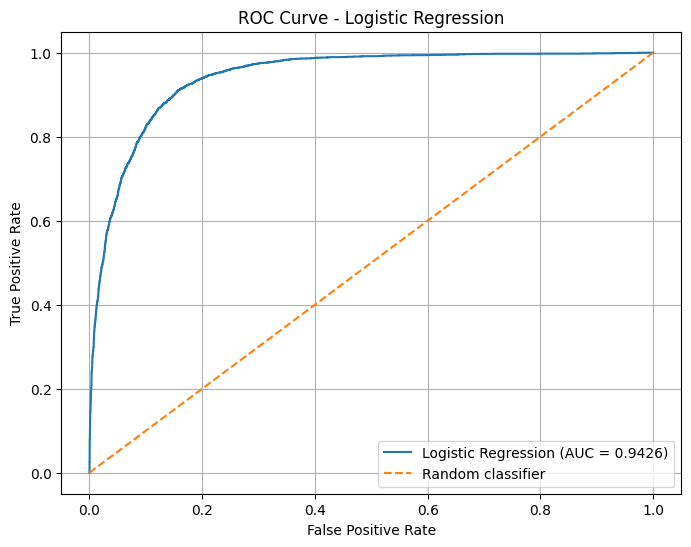

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
auc_score = roc_auc_score(y_val, y_val_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

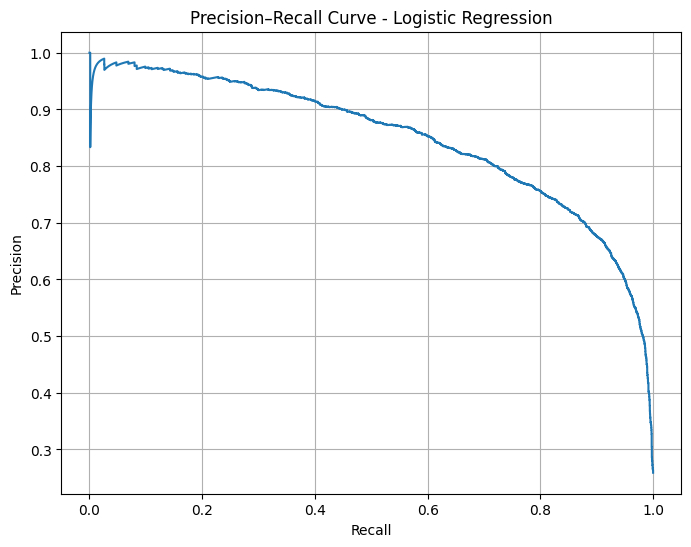

In [36]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve - Logistic Regression')
plt.grid(True)
plt.show()

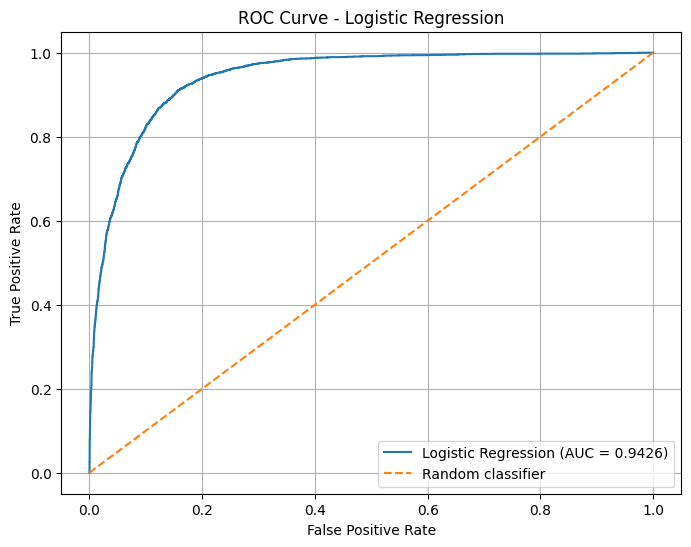

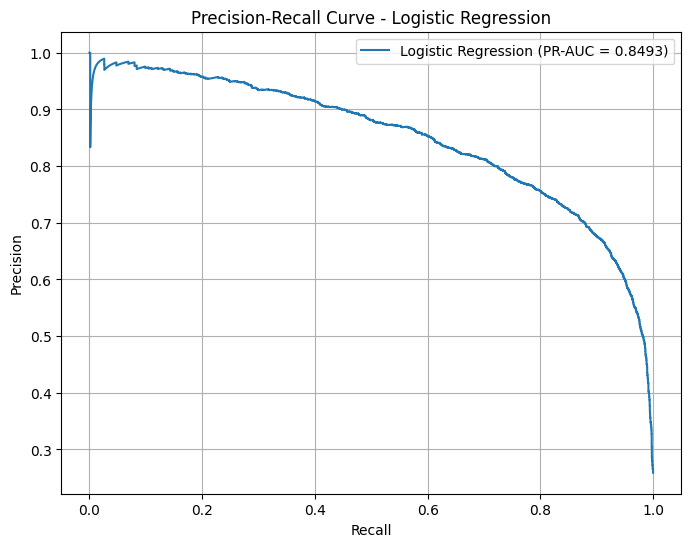

 Graphs saved successfully!

ROC Curve:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/figures/logistic_regression_roc_curve.png

Precision-Recall Curve:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/figures/logistic_regression_precision_recall_curve.png


In [37]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# Project figure folder
FIGURES_PATH = os.path.join(
    PROJECT_PATH,
    "results",
    "figures"
)

os.makedirs(FIGURES_PATH, exist_ok=True)

# ============================================================
# 1. ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(y_val, y_val_prob)
roc_auc = roc_auc_score(y_val, y_val_prob)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)

roc_path = os.path.join(
    FIGURES_PATH,
    "logistic_regression_roc_curve.png"
)

plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ============================================================
# 2. PRECISION-RECALL CURVE
# ============================================================

precision, recall, _ = precision_recall_curve(
    y_val,
    y_val_prob
)

pr_auc = average_precision_score(
    y_val,
    y_val_prob
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (PR-AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.grid(True)

pr_path = os.path.join(
    FIGURES_PATH,
    "logistic_regression_precision_recall_curve.png"
)

plt.savefig(pr_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ============================================================
# CONFIRM SAVED FILES
# ============================================================

print(" Graphs saved successfully!")
print()
print("ROC Curve:")
print(roc_path)

print()
print("Precision-Recall Curve:")
print(pr_path)

In [38]:
from xgboost import XGBClassifier

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# Train XGBoost
xgb_model.fit(
    X_train_imputed,
    y_train
)

print(" XGBoost model trained successfully!")

 XGBoost model trained successfully!


In [39]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# XGBoost validation predictions
xgb_val_prob = xgb_model.predict_proba(X_val_imputed)[:, 1]
xgb_val_pred = (xgb_val_prob >= 0.5).astype(int)

# Evaluation metrics
xgb_roc_auc = roc_auc_score(y_val, xgb_val_prob)
xgb_pr_auc = average_precision_score(y_val, xgb_val_prob)
xgb_accuracy = accuracy_score(y_val, xgb_val_pred)
xgb_precision = precision_score(y_val, xgb_val_pred)
xgb_recall = recall_score(y_val, xgb_val_pred)
xgb_f1 = f1_score(y_val, xgb_val_pred)

print("XGBoost Validation Results")
print("=" * 40)
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, xgb_val_pred))

XGBoost Validation Results
ROC-AUC  : 0.9485
PR-AUC   : 0.8679
Accuracy : 0.8874
Precision: 0.7859
Recall   : 0.7766
F1-Score : 0.7812

Confusion Matrix:
[[9608  767]
 [ 810 2815]]


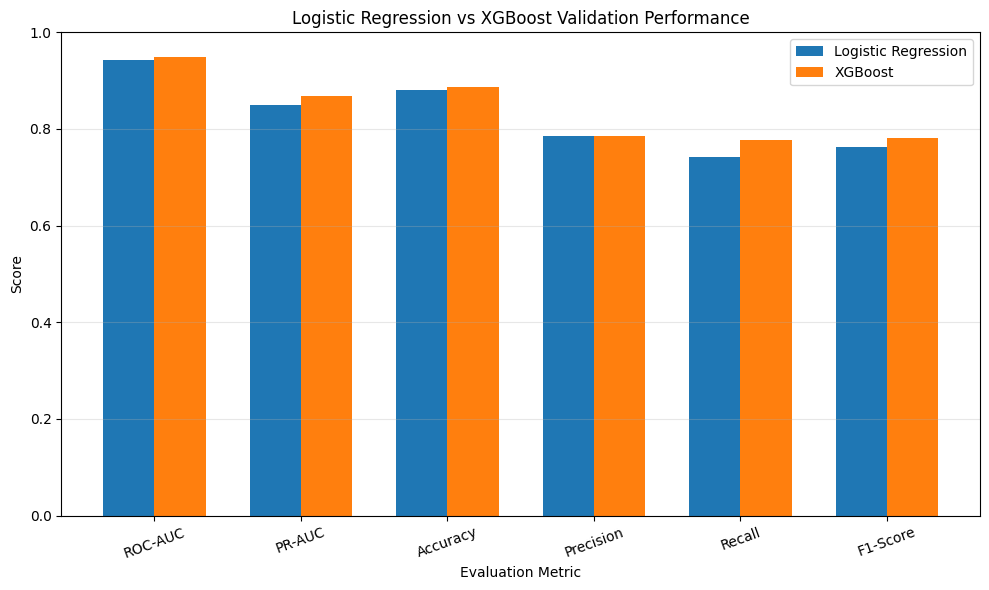

✅ Saved:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/figures/logistic_regression_vs_xgboost_comparison.png


In [40]:

import matplotlib.pyplot as plt


metrics = [
    "ROC-AUC",
    "PR-AUC",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

logistic_scores = [
    0.9426,
    0.8493,
    0.8804,
    0.7852,
    0.7410,
    0.7624
]

xgb_scores = [
    0.9485,
    0.8679,
    0.8874,
    0.7859,
    0.7766,
    0.7812
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, logistic_scores, width, label="Logistic Regression")
plt.bar(x + width/2, xgb_scores, width, label="XGBoost")

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.title("Logistic Regression vs XGBoost Validation Performance")
plt.xticks(x, metrics, rotation=20)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

comparison_path = os.path.join(
    FIGURES_PATH,
    "logistic_regression_vs_xgboost_comparison.png"
)

plt.savefig(comparison_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("✅ Saved:")
print(comparison_path)

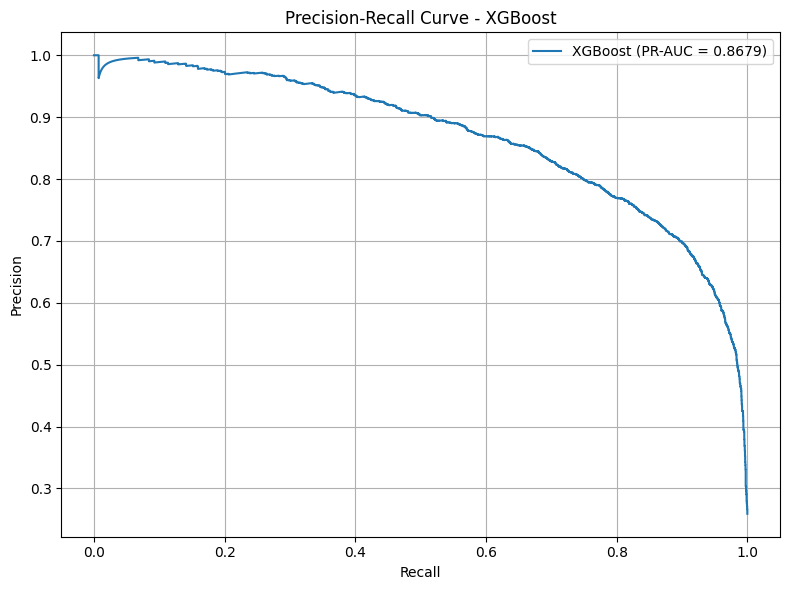

✅ Saved:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/figures/xgboost_precision_recall_curve.png


In [41]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall values
precision, recall, thresholds = precision_recall_curve(
    y_val,
    xgb_val_prob
)

# Calculate PR-AUC
pr_auc = average_precision_score(
    y_val,
    xgb_val_prob
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"XGBoost (PR-AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.legend()
plt.grid(True)

plt.tight_layout()

# Save
pr_xgb_path = os.path.join(
    FIGURES_PATH,
    "xgboost_precision_recall_curve.png"
)

plt.savefig(
    pr_xgb_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Saved:")
print(pr_xgb_path)

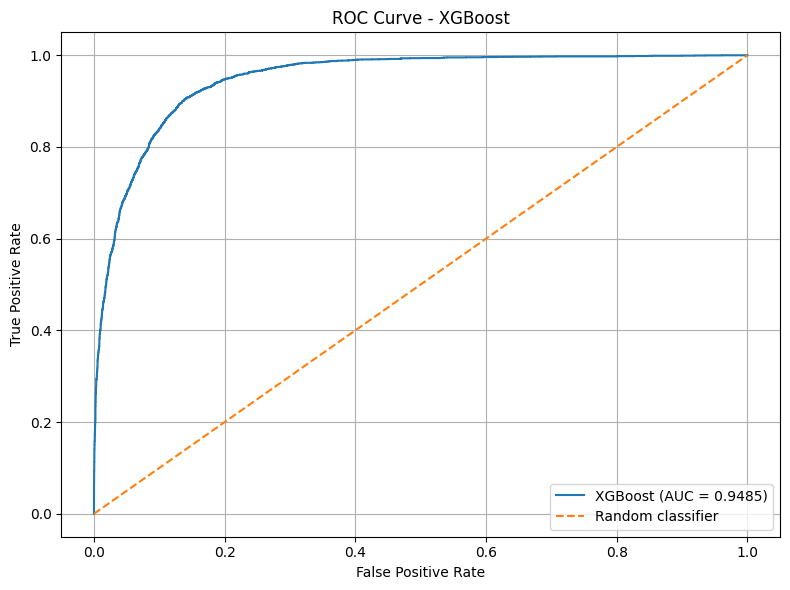

✅ Saved:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/figures/xgboost_roc_curve.png


In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import os

# Calculate ROC values
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(
    y_val,
    xgb_val_prob
)

# Calculate ROC-AUC
roc_auc_xgb = roc_auc_score(
    y_val,
    xgb_val_prob
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_xgb:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)

plt.tight_layout()

# Save
roc_xgb_path = os.path.join(
    FIGURES_PATH,
    "xgboost_roc_curve.png"
)

plt.savefig(
    roc_xgb_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Saved:")
print(roc_xgb_path)

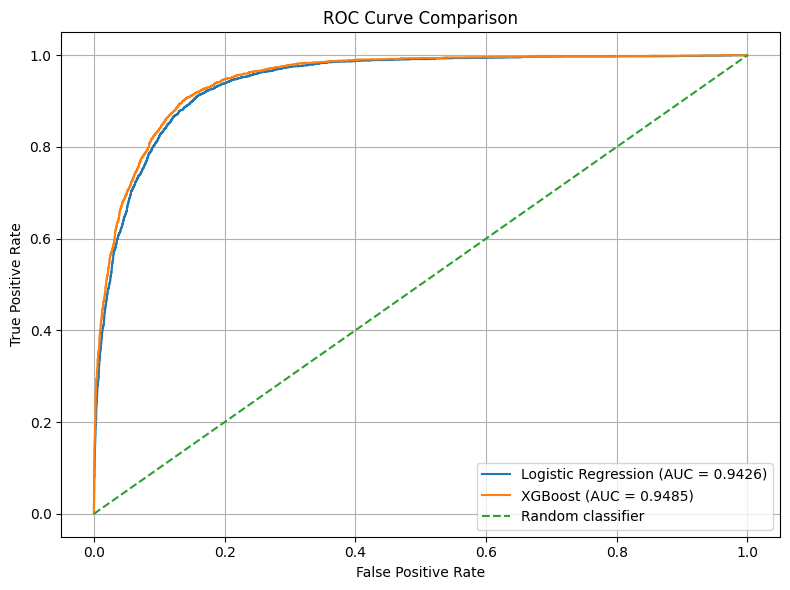

✅ ROC comparison saved:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/figures/logistic_vs_xgboost_roc_comparison.png


NameError: name 'recall_xgb' is not defined

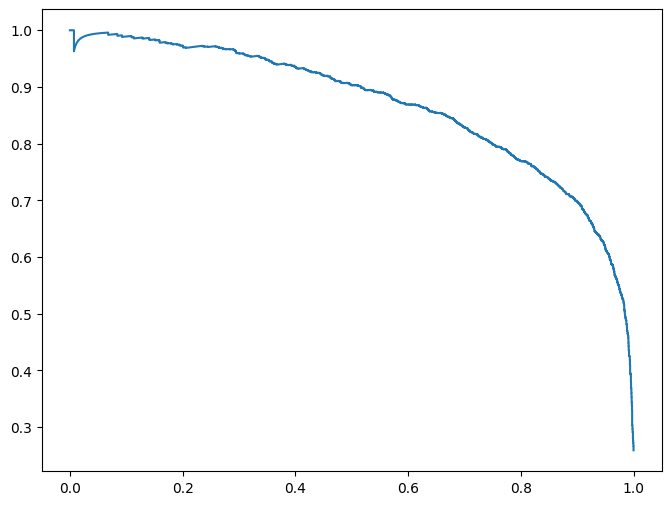

In [43]:
import matplotlib.pyplot as plt
import os

# ============================================================
# 1. Combined ROC Curve
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr, tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    fpr_xgb, tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_xgb:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()

roc_comparison_path = os.path.join(
    FIGURES_PATH,
    "logistic_vs_xgboost_roc_comparison.png"
)

plt.savefig(
    roc_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ ROC comparison saved:")
print(roc_comparison_path)


# ============================================================
# 2. Combined Precision-Recall Curve
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (PR-AUC = {pr_auc:.4f})"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost (PR-AUC = {pr_auc_xgb:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()

pr_comparison_path = os.path.join(
    FIGURES_PATH,
    "logistic_vs_xgboost_pr_comparison.png"
)

plt.savefig(
    pr_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Precision-Recall comparison saved:")
print(pr_comparison_path)

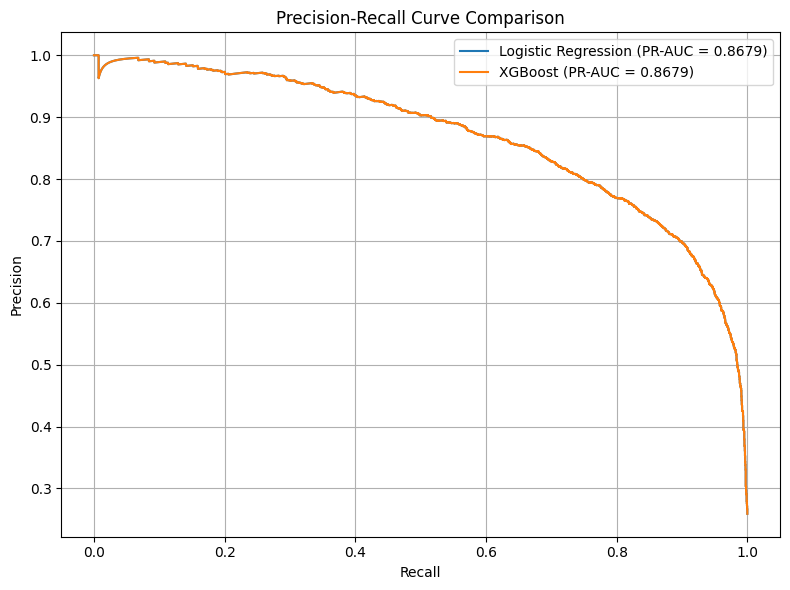

✅ Precision-Recall comparison saved:
/content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/results/figures/logistic_vs_xgboost_pr_comparison.png
XGBoost PR-AUC: 0.8679


In [44]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import os

# Calculate XGBoost Precision-Recall values
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_val,
    xgb_val_prob
)

# Calculate XGBoost PR-AUC
pr_auc_xgb = average_precision_score(
    y_val,
    xgb_val_prob
)

# Plot comparison
plt.figure(figsize=(8, 6))

plt.plot(
    recall, precision,
    label=f"Logistic Regression (PR-AUC = {pr_auc:.4f})"
)

plt.plot(
    recall_xgb, precision_xgb,
    label=f"XGBoost (PR-AUC = {pr_auc_xgb:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()

pr_comparison_path = os.path.join(
    FIGURES_PATH,
    "logistic_vs_xgboost_pr_comparison.png"
)

plt.savefig(
    pr_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Precision-Recall comparison saved:")
print(pr_comparison_path)
print(f"XGBoost PR-AUC: {pr_auc_xgb:.4f}")

In [45]:

import joblib

# Create models folder
MODELS_PATH = os.path.join(PROJECT_PATH, "models")
os.makedirs(MODELS_PATH, exist_ok=True)

# Save Logistic Regression model
joblib.dump(
    logistic_model,
    os.path.join(MODELS_PATH, "logistic_regression.pkl")
)

# Save XGBoost model
joblib.dump(
    xgb_model,
    os.path.join(MODELS_PATH, "xgboost_model.pkl")
)

# Save preprocessing objects
joblib.dump(
    imputer,
    os.path.join(MODELS_PATH, "median_imputer.pkl")
)

joblib.dump(
    scaler,
    os.path.join(MODELS_PATH, "standard_scaler.pkl")
)

print("✅ All models and preprocessing objects saved!")
print()
print("📁 Location:", MODELS_PATH)
print()
print("Files:")
for file in os.listdir(MODELS_PATH):
    print("  ✅", file)

✅ All models and preprocessing objects saved!

📁 Location: /content/drive/MyDrive/AMEX_Credit_Risk_Capstone_Project/models

Files:
  ✅ logistic_regression.pkl
  ✅ xgboost_model.pkl
  ✅ median_imputer.pkl
  ✅ standard_scaler.pkl
